In [1]:
import pandas as pd

In [2]:
import numpy as np      # To use np.arrays
from pandas.plotting import autocorrelation_plot as auto_corr

# To plot
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
import seaborn as sns

#For date-time
import math
from datetime import datetime
from datetime import timedelta

In [3]:
df_store = pd.read_csv('stores.csv')

In [4]:
df_features = pd.read_csv('features.csv')

In [5]:
df_train = pd.read_csv('train.csv/train.csv')

In [6]:
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [7]:
df_features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [8]:
df_store.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [9]:
df = df_features.merge(df_train, on=['Store','Date'], how='inner').merge(df_store, on=['Store'], how='inner')

In [10]:
df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_x,Dept,Weekly_Sales,IsHoliday_y,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,1,24924.50,False,A,151315
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2,50605.27,False,A,151315
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,3,13740.12,False,A,151315
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,4,39954.04,False,A,151315
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,5,32229.38,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,93,2487.80,False,B,118221
421566,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,94,5203.31,False,B,118221
421567,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,95,56017.47,False,B,118221
421568,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,97,6817.48,False,B,118221


In [11]:
df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_x,Dept,Weekly_Sales,IsHoliday_y,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,1,24924.50,False,A,151315
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2,50605.27,False,A,151315
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,3,13740.12,False,A,151315
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,4,39954.04,False,A,151315
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,5,32229.38,False,A,151315


In [12]:
df.drop(['IsHoliday_y'], axis=1, inplace=True)

In [13]:
df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_x,Dept,Weekly_Sales,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,1,24924.50,A,151315
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2,50605.27,A,151315
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,3,13740.12,A,151315
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,4,39954.04,A,151315
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,5,32229.38,A,151315


In [14]:
df.rename(columns={'IsHoliday_x':'IsHoliday'}, inplace=True)

In [15]:
df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Dept,Weekly_Sales,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,1,24924.50,A,151315
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2,50605.27,A,151315
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,3,13740.12,A,151315
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,4,39954.04,A,151315
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,5,32229.38,A,151315


In [16]:
df.shape

(421570, 16)

In [17]:
df['Store'].nunique()

45

In [18]:
df['Dept'].nunique()

81

In [19]:
df['IsHoliday'].value_counts()

IsHoliday
False    391909
True      29661
Name: count, dtype: int64

In [20]:
store_dept_table = pd.pivot_table(df, index='Store', columns='Dept', values='Weekly_Sales', aggfunc=np.mean)

C:\Users\Krishna\AppData\Local\Temp\ipykernel_20416\182756757.py:1: FutureWarning: The provided callable <function mean at 0x0000011E89AA4F40> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  store_dept_table = pd.pivot_table(df, index='Store', columns='Dept', values='Weekly_Sales', aggfunc=np.mean)


In [21]:
display(store_dept_table)

Dept,1,2,3,4,5,6,7,8,9,10,...,90,91,92,93,94,95,96,97,98,99
Store,,,,,,,,,,,,,,,,,,,,,
1,22513.322937,46102.090420,13150.478042,36964.154476,24257.941119,4801.780140,24566.487413,35718.257622,28062.052238,31033.386364,...,82427.547832,64238.943427,135458.969510,71699.182378,63180.568182,120772.062168,33251.831639,35207.348811,11827.770769,306.091081
2,30777.980769,65912.922517,17476.563357,45607.666573,30555.315315,6808.382517,40477.837063,58707.369441,34375.864476,38845.854476,...,97611.537133,80610.380350,164840.230979,70581.977063,70018.672517,143588.751888,34319.063846,40697.204056,14035.400839,475.896905
3,7328.621049,16841.775664,5509.300769,8434.186503,11695.366573,2012.411818,10044.341608,8310.254196,9062.007692,10871.944126,...,1540.049161,318.685594,7568.280210,NaN,656.294444,15745.528252,3934.540000,343.437357,30.570833,NaN
4,36979.940070,93639.315385,19012.491678,56603.400140,45668.406783,8241.777692,50728.151399,62949.723776,34437.170979,37269.667413,...,89248.965524,66535.407203,159365.107902,67815.163007,68159.106573,147236.473706,38346.573077,39339.238951,15009.249371,623.182381
5,9774.553077,12317.953287,4101.085175,9860.806783,6699.202238,1191.057622,6124.484336,13735.709441,7919.805944,9783.395385,...,3059.520000,1457.221678,7759.205594,NaN,411.431486,19340.693986,5985.671119,667.070315,29.976087,NaN
6,23867.553776,50269.437273,16806.638811,34187.366503,34465.307622,7225.566643,34526.870420,47577.719790,48271.060140,47436.477902,...,53715.366084,45270.405175,99024.796503,41359.651189,41701.693497,89208.786294,30450.542238,20637.667063,9728.100629,388.636750
7,9542.801259,22603.690769,8633.536923,14950.518601,13860.350490,6329.928811,10925.757063,13970.619371,29722.736084,21136.560280,...,13858.405874,10263.880000,26530.890559,1328.178252,699.332522,34208.097273,1123.383217,4374.927902,260.886596,15.000000
8,14789.827343,35729.821748,10683.305105,21089.309301,19838.849231,3395.425455,20268.743776,26438.524336,11792.661678,20666.433776,...,39333.566154,31530.560909,60465.630000,27515.635315,25442.578042,62951.463706,16.986667,16978.366503,6880.466434,298.153714
9,11846.558252,24969.477413,7497.356783,17165.947762,19282.746014,2806.416364,13826.694336,21424.470699,13196.569720,12810.480350,...,2981.249510,869.273287,14123.063147,21.240000,599.112568,29575.050769,3596.107762,372.655556,27.930000,NaN


In [22]:
df.loc[df['Weekly_Sales']<=0]

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Dept,Weekly_Sales,Type,Size
188,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,47,-863.00,A,151315
406,1,2010-03-12,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False,47,-698.00,A,151315
2549,1,2010-10-08,63.93,2.633,NaN,NaN,NaN,NaN,NaN,211.746754,7.838,False,47,-58.00,A,151315
3632,1,2011-01-21,44.04,3.016,NaN,NaN,NaN,NaN,NaN,211.827234,7.742,False,54,-50.00,A,151315
4132,1,2011-03-11,53.56,3.459,NaN,NaN,NaN,NaN,NaN,214.111056,7.742,False,47,0.00,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420066,45,2012-05-25,67.21,3.798,5370.39,NaN,361.22,1287.62,2461.81,191.002810,8.567,False,49,-4.97,B,118221
420403,45,2012-06-29,75.22,3.506,3291.36,425.60,NaN,314.88,2255.34,191.099246,8.567,False,49,-34.00,B,118221
420736,45,2012-08-03,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,191.164090,8.684,False,49,-1.91,B,118221
421007,45,2012-08-31,75.09,3.867,23641.30,6.00,92.93,6988.31,3992.13,191.461281,8.684,False,54,0.00,B,118221


In [23]:
df = df.loc[df['Weekly_Sales']>0]

In [24]:
df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Dept,Weekly_Sales,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,1,24924.50,A,151315
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2,50605.27,A,151315
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,3,13740.12,A,151315
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,4,39954.04,A,151315
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,5,32229.38,A,151315


In [25]:
df.shape

(420212, 16)

In [26]:
df['Date']

0         2010-02-05
1         2010-02-05
2         2010-02-05
3         2010-02-05
4         2010-02-05
             ...    
421565    2012-10-26
421566    2012-10-26
421567    2012-10-26
421568    2012-10-26
421569    2012-10-26
Name: Date, Length: 420212, dtype: object

<Axes: xlabel='IsHoliday', ylabel='Weekly_Sales'>

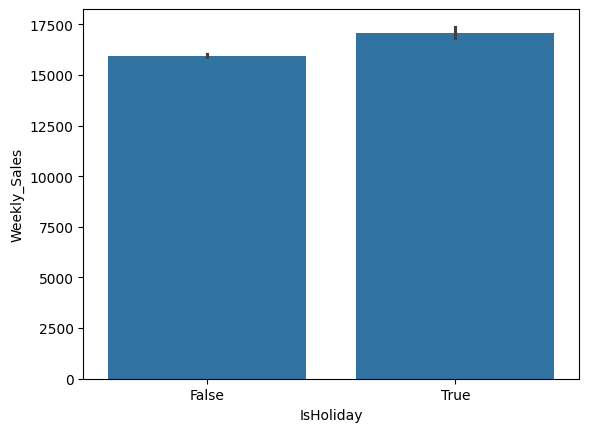

In [27]:
sns.barplot(x='IsHoliday', y='Weekly_Sales', data=df)

In [28]:
df_holiday = df.loc[df['IsHoliday']==True]

In [29]:
df_holiday['Date'].nunique()

10

In [30]:
df_holiday['Date'].count()

np.int64(29560)

In [31]:
df_not_holiday=df.loc[df['IsHoliday']==False]

In [32]:
df_not_holiday['Date'].nunique()

133

In [33]:
df_holiday['Date'].unique()

array(['2010-02-12', '2010-09-10', '2010-11-26', '2010-12-31',
       '2011-02-11', '2011-09-09', '2011-11-25', '2011-12-30',
       '2012-02-10', '2012-09-07'], dtype=object)

In [34]:
# Super bowl dates in train set
df.loc[(df['Date'] == '2010-02-12')|(df['Date'] == '2011-02-11')|(df['Date'] == '2012-02-10'),'Super_Bowl'] = True
df.loc[(df['Date'] != '2010-02-12')&(df['Date'] != '2011-02-11')&(df['Date'] != '2012-02-10'),'Super_Bowl'] = False

C:\Users\Krishna\AppData\Local\Temp\ipykernel_20416\38026190.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df['Date'] == '2010-02-12')|(df['Date'] == '2011-02-11')|(df['Date'] == '2012-02-10'),'Super_Bowl'] = True


In [35]:
df.shape


(420212, 17)

In [36]:
df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Dept,Weekly_Sales,Type,Size,Super_Bowl
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,1,24924.50,A,151315,False
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2,50605.27,A,151315,False
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,3,13740.12,A,151315,False
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,4,39954.04,A,151315,False
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,5,32229.38,A,151315,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,93,2487.80,B,118221,False
421566,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,94,5203.31,B,118221,False
421567,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,95,56017.47,B,118221,False
421568,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,97,6817.48,B,118221,False


In [37]:
# Labor day dates in train set
df.loc[(df['Date'] == '2010-09-10')|(df['Date'] == '2011-09-09')|(df['Date'] == '2012-09-07'),'Labor_Day'] = True
df.loc[(df['Date'] != '2010-09-10')&(df['Date'] != '2011-09-09')&(df['Date'] != '2012-09-07'),'Labor_Day'] = False

C:\Users\Krishna\AppData\Local\Temp\ipykernel_20416\1349597063.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df['Date'] == '2010-09-10')|(df['Date'] == '2011-09-09')|(df['Date'] == '2012-09-07'),'Labor_Day'] = True


In [38]:
# Thanksgiving dates in train set
df.loc[(df['Date'] == '2010-11-26')|(df['Date'] == '2011-11-25'),'Thanksgiving'] = True
df.loc[(df['Date'] != '2010-11-26')&(df['Date'] != '2011-11-25'),'Thanksgiving'] = False

C:\Users\Krishna\AppData\Local\Temp\ipykernel_20416\2744260695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df['Date'] == '2010-11-26')|(df['Date'] == '2011-11-25'),'Thanksgiving'] = True


In [39]:
#Christmas dates in train set
df.loc[(df['Date'] == '2010-12-31')|(df['Date'] == '2011-12-30'),'Christmas'] = True
df.loc[(df['Date'] != '2010-12-31')&(df['Date'] != '2011-12-30'),'Christmas'] = False

C:\Users\Krishna\AppData\Local\Temp\ipykernel_20416\3756870649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df['Date'] == '2010-12-31')|(df['Date'] == '2011-12-30'),'Christmas'] = True


In [40]:
df.shape

(420212, 20)

<Axes: xlabel='Super_Bowl', ylabel='Weekly_Sales'>

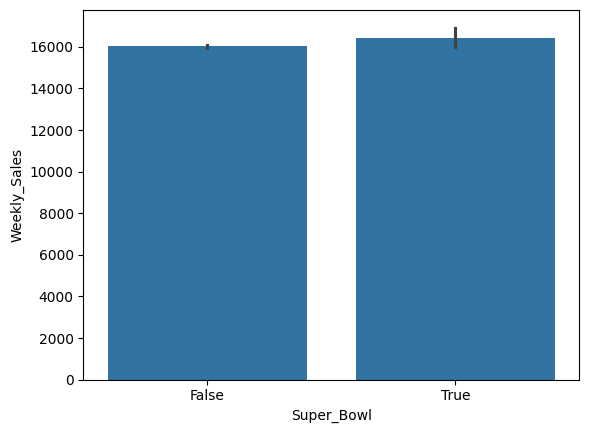

In [41]:
sns.barplot(x='Super_Bowl', y='Weekly_Sales', data=df)

<Axes: xlabel='Thanksgiving', ylabel='Weekly_Sales'>

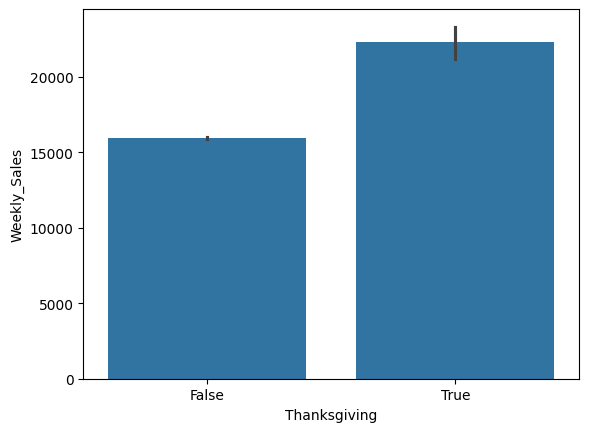

In [42]:
sns.barplot(x='Thanksgiving', y='Weekly_Sales', data=df)

<Axes: xlabel='Christmas', ylabel='Weekly_Sales'>

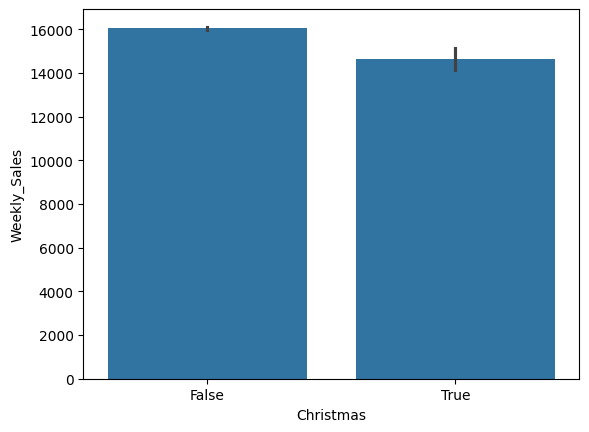

In [43]:
sns.barplot(x='Christmas',y='Weekly_Sales', data=df) 

In [44]:
#beforeChristmas dates in train set
df.loc[(df['Date'] == '2010-12-24')|(df['Date'] == '2011-12-25'),'before_Christmas'] = True
df.loc[(df['Date'] != '2010-12-24')&(df['Date'] != '2011-12-25'),'before_Christmas'] = False

C:\Users\Krishna\AppData\Local\Temp\ipykernel_20416\2105235397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df['Date'] == '2010-12-24')|(df['Date'] == '2011-12-25'),'before_Christmas'] = True


<Axes: xlabel='before_Christmas', ylabel='Weekly_Sales'>

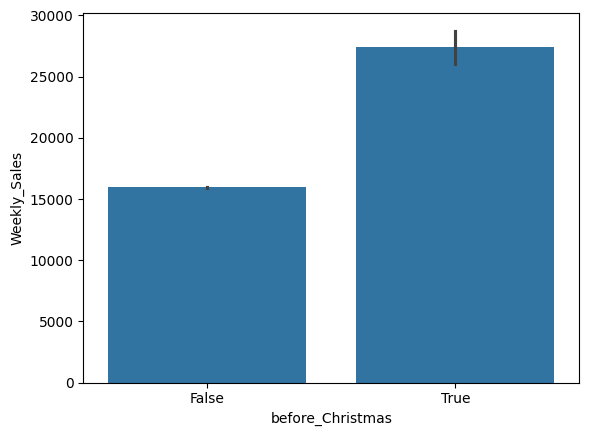

In [45]:
sns.barplot(x='before_Christmas',y='Weekly_Sales', data=df) 

<Axes: xlabel='Labor_Day', ylabel='Weekly_Sales'>

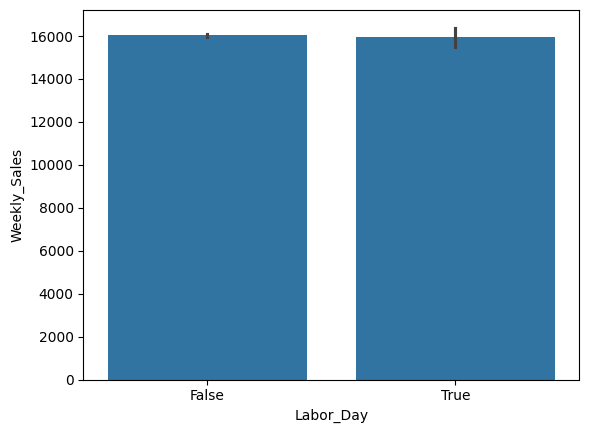

In [46]:
sns.barplot(x='Labor_Day', y='Weekly_Sales', data=df)

In [47]:
df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,IsHoliday,Dept,Weekly_Sales,Type,Size,Super_Bowl,Labor_Day,Thanksgiving,Christmas,before_Christmas
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,False,1,24924.50,A,151315,False,False,False,False,False
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,False,2,50605.27,A,151315,False,False,False,False,False
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,False,3,13740.12,A,151315,False,False,False,False,False
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,False,4,39954.04,A,151315,False,False,False,False,False
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,False,5,32229.38,A,151315,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,False,93,2487.80,B,118221,False,False,False,False,False
421566,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,False,94,5203.31,B,118221,False,False,False,False,False
421567,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,False,95,56017.47,B,118221,False,False,False,False,False
421568,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,False,97,6817.48,B,118221,False,False,False,False,False


In [48]:
df.groupby(['Christmas','Type'])['Weekly_Sales'].mean()

Christmas  Type
False      A       20174.350209
           B       12301.986116
           C        9570.951973
True       A       18310.167535
           B       11488.988057
           C        8031.520607
Name: Weekly_Sales, dtype: float64

In [49]:
df.groupby(['before_Christmas','Type'])['Weekly_Sales'].mean()

before_Christmas  Type
False             A       20049.651146
                  B       12214.574981
                  C        9543.213410
True              A       34038.030813
                  B       22987.772578
                  C       10453.892302
Name: Weekly_Sales, dtype: float64

In [50]:
df.groupby(['Labor_Day','Type'])['Weekly_Sales'].mean()

Labor_Day  Type
False      A       20151.210941
           B       12294.954138
           C        9542.098293
True       A       20004.267422
           B       12084.304642
           C        9893.459258
Name: Weekly_Sales, dtype: float64

In [51]:
df.groupby(['Thanksgiving','Type'])['Weekly_Sales'].mean()

Thanksgiving  Type
False         A       20044.007801
              B       12197.717405
              C        9547.377807
True          A       27397.776346
              B       18733.973971
              C        9696.566616
Name: Weekly_Sales, dtype: float64

In [52]:
df.groupby(['Super_Bowl','Type'])['Weekly_Sales'].mean()

Super_Bowl  Type
False       A       20138.055908
            B       12286.739293
            C        9536.110508
True        A       20612.757674
            B       12467.035506
            C       10179.271884
Name: Weekly_Sales, dtype: float64

In [53]:
stores_sales = df.groupby('Type')['Weekly_Sales'].sum().reset_index()

In [54]:
display(stores_sales)

,Type,Weekly_Sales
0,A,4.331057e+09
1,B,2.000742e+09
2,C,4.055080e+08


In [55]:
total_sales = stores_sales['Weekly_Sales'].sum()

In [56]:
display(total_sales)

np.float64(6737307148.67)

In [57]:
stores_sales['Percentage'] = (stores_sales['Weekly_Sales']/total_sales)*100

In [58]:
print(stores_sales)

  Type  Weekly_Sales  Percentage
0    A  4.331057e+09   64.284697
1    B  2.000742e+09   29.696459
2    C  4.055080e+08    6.018844


In [59]:
type_sales = df.groupby('Type')['Weekly_Sales'].sum()

In [60]:
total_sales2 = type_sales.sum()

In [61]:
display(total_sales2)

np.float64(6737307148.67)

In [62]:
percentage = (type_sales/total_sales2)*100

In [63]:
display(percentage)

Type
A    64.284697
B    29.696459
C     6.018844
Name: Weekly_Sales, dtype: float64

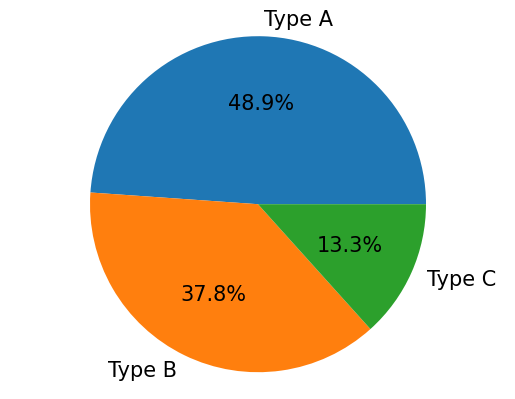

In [64]:
my_data = [48.88, 37.77 , 13.33 ]  #percentages
my_labels = 'Type A','Type B', 'Type C' # labels
plt.pie(my_data,labels=my_labels,autopct='%1.1f%%', textprops={'fontsize': 15}) #plot pie type and bigger the labels
plt.axis('equal')
mpl.rcParams.update({'font.size': 20}) #bigger percentage labels

plt.show()

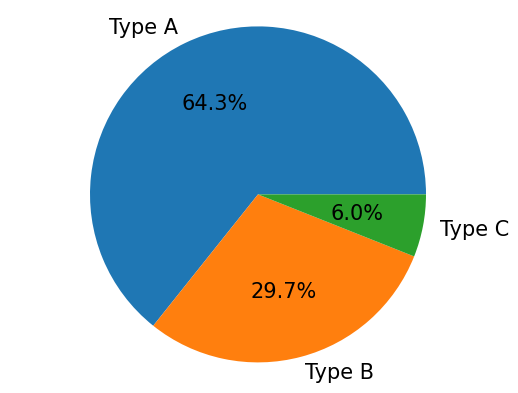

In [65]:
my_data = stores_sales['Percentage'] #percentages
my_labels = 'Type A','Type B', 'Type C' # labels
plt.pie(my_data,labels=my_labels,autopct='%1.1f%%', textprops={'fontsize': 15}) #plot pie type and bigger the labels
plt.axis('equal')
mpl.rcParams.update({'font.size': 20}) #bigger percentage labels

plt.show()

In [66]:
df.groupby('IsHoliday')['Weekly_Sales'].mean()

IsHoliday
False    15952.816352
True     17094.300918
Name: Weekly_Sales, dtype: float64

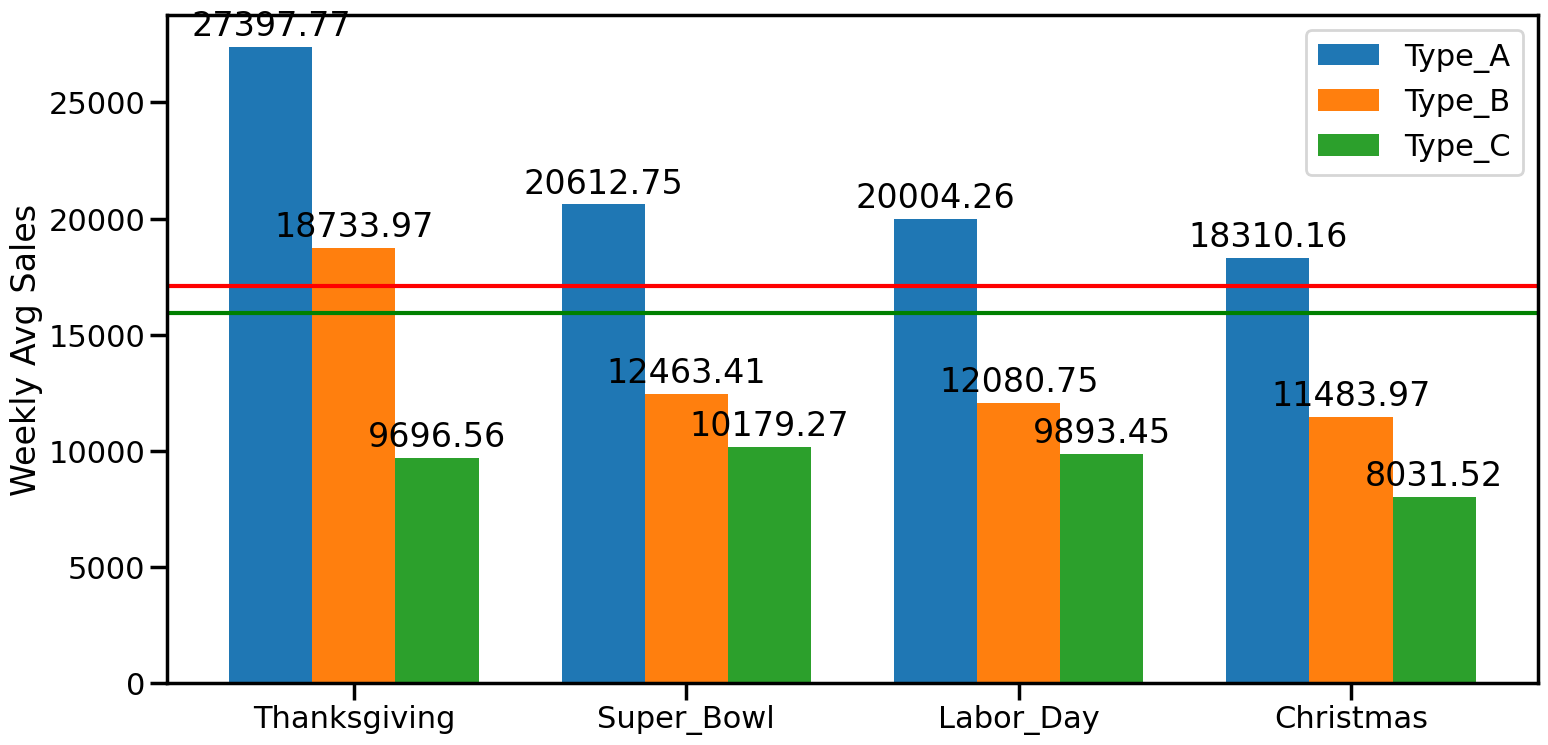

In [67]:
# Plotting avg wekkly sales according to holidays by types
sns.set_context("poster")
labels = ['Thanksgiving', 'Super_Bowl', 'Labor_Day', 'Christmas']
A_means = [27397.77, 20612.75, 20004.26, 18310.16]
B_means = [18733.97, 12463.41, 12080.75, 11483.97]
C_means = [9696.56,10179.27,9893.45,8031.52]

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(16, 8))
rects1 = ax.bar(x - width, A_means, width, label='Type_A')
rects2 = ax.bar(x , B_means, width, label='Type_B')
rects3 = ax.bar(x + width, C_means, width, label='Type_C')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Weekly Avg Sales')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.axhline(y=17094.30,color='r') # holidays avg
plt.axhline(y=15952.82,color='green') # not-holiday avg

fig.tight_layout()

plt.show()

In [68]:
df.sort_values(by='Weekly_Sales',ascending=False).head(5)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,IsHoliday,Dept,Weekly_Sales,Type,Size,Super_Bowl,Labor_Day,Thanksgiving,Christmas,before_Christmas
90645,10,2010-11-26,55.33,3.162,NaN,NaN,NaN,NaN,NaN,126.669267,...,True,72,693099.36,B,126512,False,False,True,False,False
337053,35,2011-11-25,47.88,3.492,1333.24,NaN,58563.24,20.97,6386.86,140.421786,...,True,72,649770.18,B,103681,False,False,True,False,False
94393,10,2011-11-25,60.68,3.760,174.72,329.0,141630.61,79.00,1009.98,129.836400,...,True,72,630999.19,B,126512,False,False,True,False,False
333594,35,2010-11-26,46.67,3.039,NaN,NaN,NaN,NaN,NaN,136.689571,...,True,72,627962.93,B,103681,False,False,True,False,False
131088,14,2010-11-26,46.15,3.039,NaN,NaN,NaN,NaN,NaN,182.783277,...,True,72,474330.10,A,200898,False,False,True,False,False


In [69]:
df_store

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [70]:
df_store.groupby('Type').describe()['Size'].round(2)

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
A,22.0,177247.73,49392.62,39690.0,155840.75,202406.0,203819.0,219622.0
B,17.0,101190.71,32371.14,34875.0,93188.00,114533.0,123737.0,140167.0
C,6.0,40541.67,1304.15,39690.0,39745.00,39910.0,40774.0,42988.0


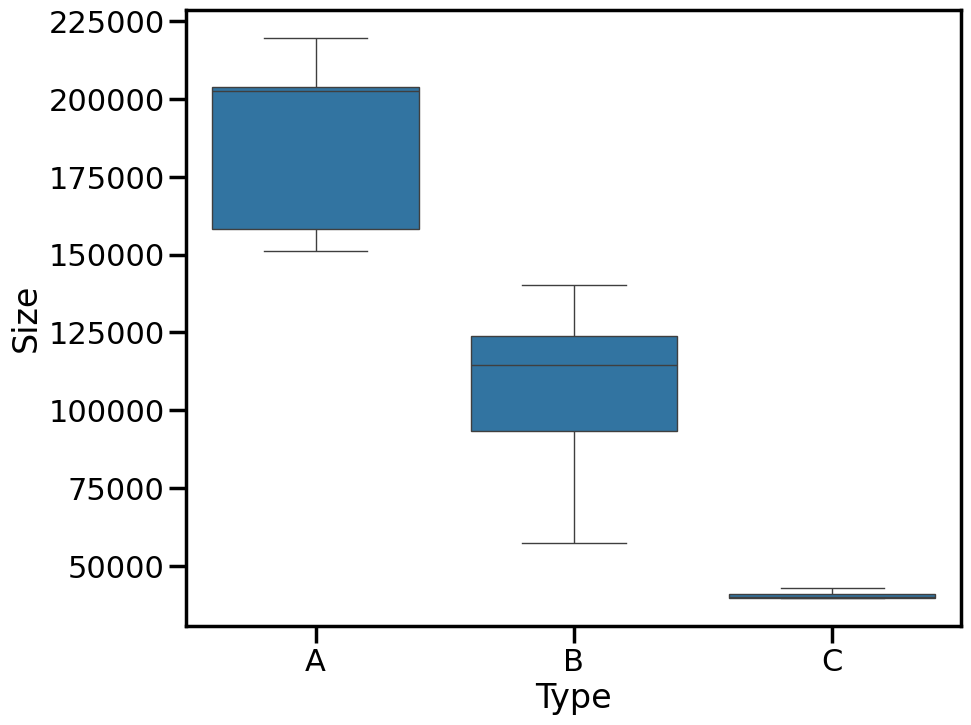

In [71]:
plt.figure(figsize=(10,8))
fig = sns.boxplot(x='Type', y='Size', data=df, showfliers=False)

In [72]:
df.groupby('Date')['MarkDown1']

In [73]:
df.isna().sum()

Store                    0
Date                     0
Temperature              0
Fuel_Price               0
MarkDown1           270031
MarkDown2           309308
MarkDown3           283561
MarkDown4           285694
MarkDown5           269283
CPI                      0
Unemployment             0
IsHoliday                0
Dept                     0
Weekly_Sales             0
Type                     0
Size                     0
Super_Bowl               0
Labor_Day                0
Thanksgiving             0
Christmas                0
before_Christmas         0
dtype: int64

In [74]:
df = df.fillna(0)

C:\Users\Krishna\AppData\Local\Temp\ipykernel_20416\3475559988.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


In [75]:
df.isna().sum()

Store               0
Date                0
Temperature         0
Fuel_Price          0
MarkDown1           0
MarkDown2           0
MarkDown3           0
MarkDown4           0
MarkDown5           0
CPI                 0
Unemployment        0
IsHoliday           0
Dept                0
Weekly_Sales        0
Type                0
Size                0
Super_Bowl          0
Labor_Day           0
Thanksgiving        0
Christmas           0
before_Christmas    0
dtype: int64

In [76]:
df.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Dept,Weekly_Sales,Size
count,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000
mean,22.195611,60.090599,3.360890,2590.323565,878.905242,468.845949,1083.534361,1662.805002,171.212496,7.960000,44.241309,16033.114591,136749.732787
std,12.787236,18.447857,0.458519,6053.415601,5076.928566,5534.069859,3896.068938,4206.209357,39.162445,1.863879,30.508819,22729.492116,60993.084568
min,1.000000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,1.000000,0.010000,34875.000000
25%,11.000000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,18.000000,2120.130000,93638.000000
50%,22.000000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.350989,7.866000,37.000000,7661.700000,140167.000000
75%,33.000000,74.280000,3.738000,2809.050000,2.400000,4.540000,425.290000,2168.040000,212.445487,8.567000,74.000000,20271.265000,202505.000000
max,45.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,99.000000,693099.360000,219622.000000


In [77]:
df['Dept'].describe()

count    420212.000000
mean         44.241309
std          30.508819
min           1.000000
25%          18.000000
50%          37.000000
75%          74.000000
max          99.000000
Name: Dept, dtype: float64

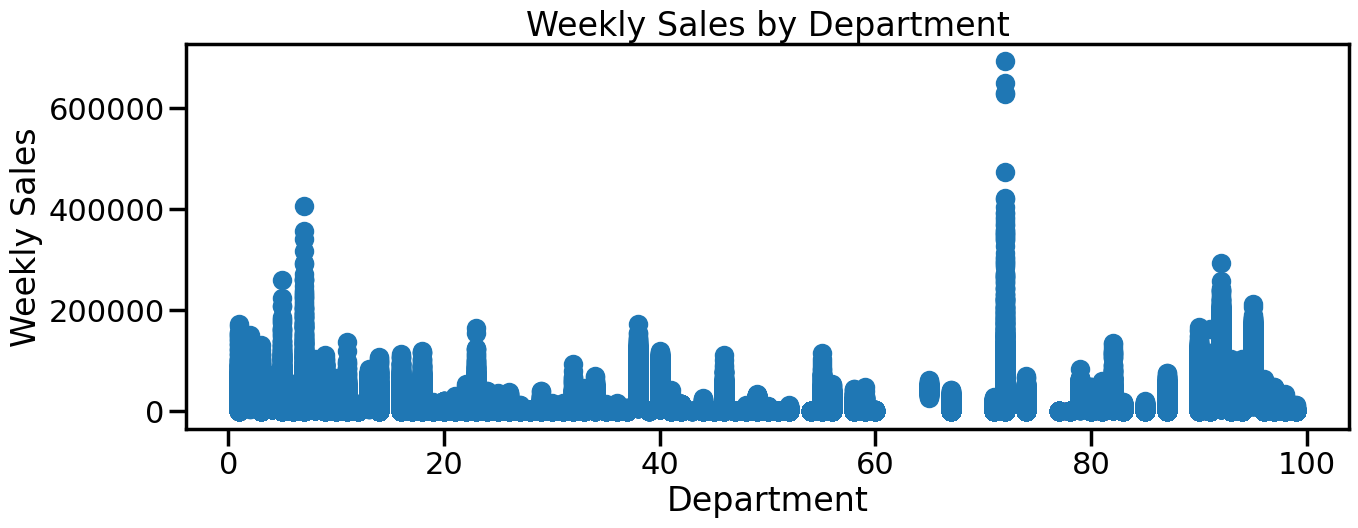

In [78]:
x = df['Dept']
y = df['Weekly_Sales']
plt.figure(figsize=(15,5))
plt.title('Weekly Sales by Department')
plt.xlabel('Department')
plt.ylabel('Weekly Sales')
plt.scatter(x,y)
plt.show()

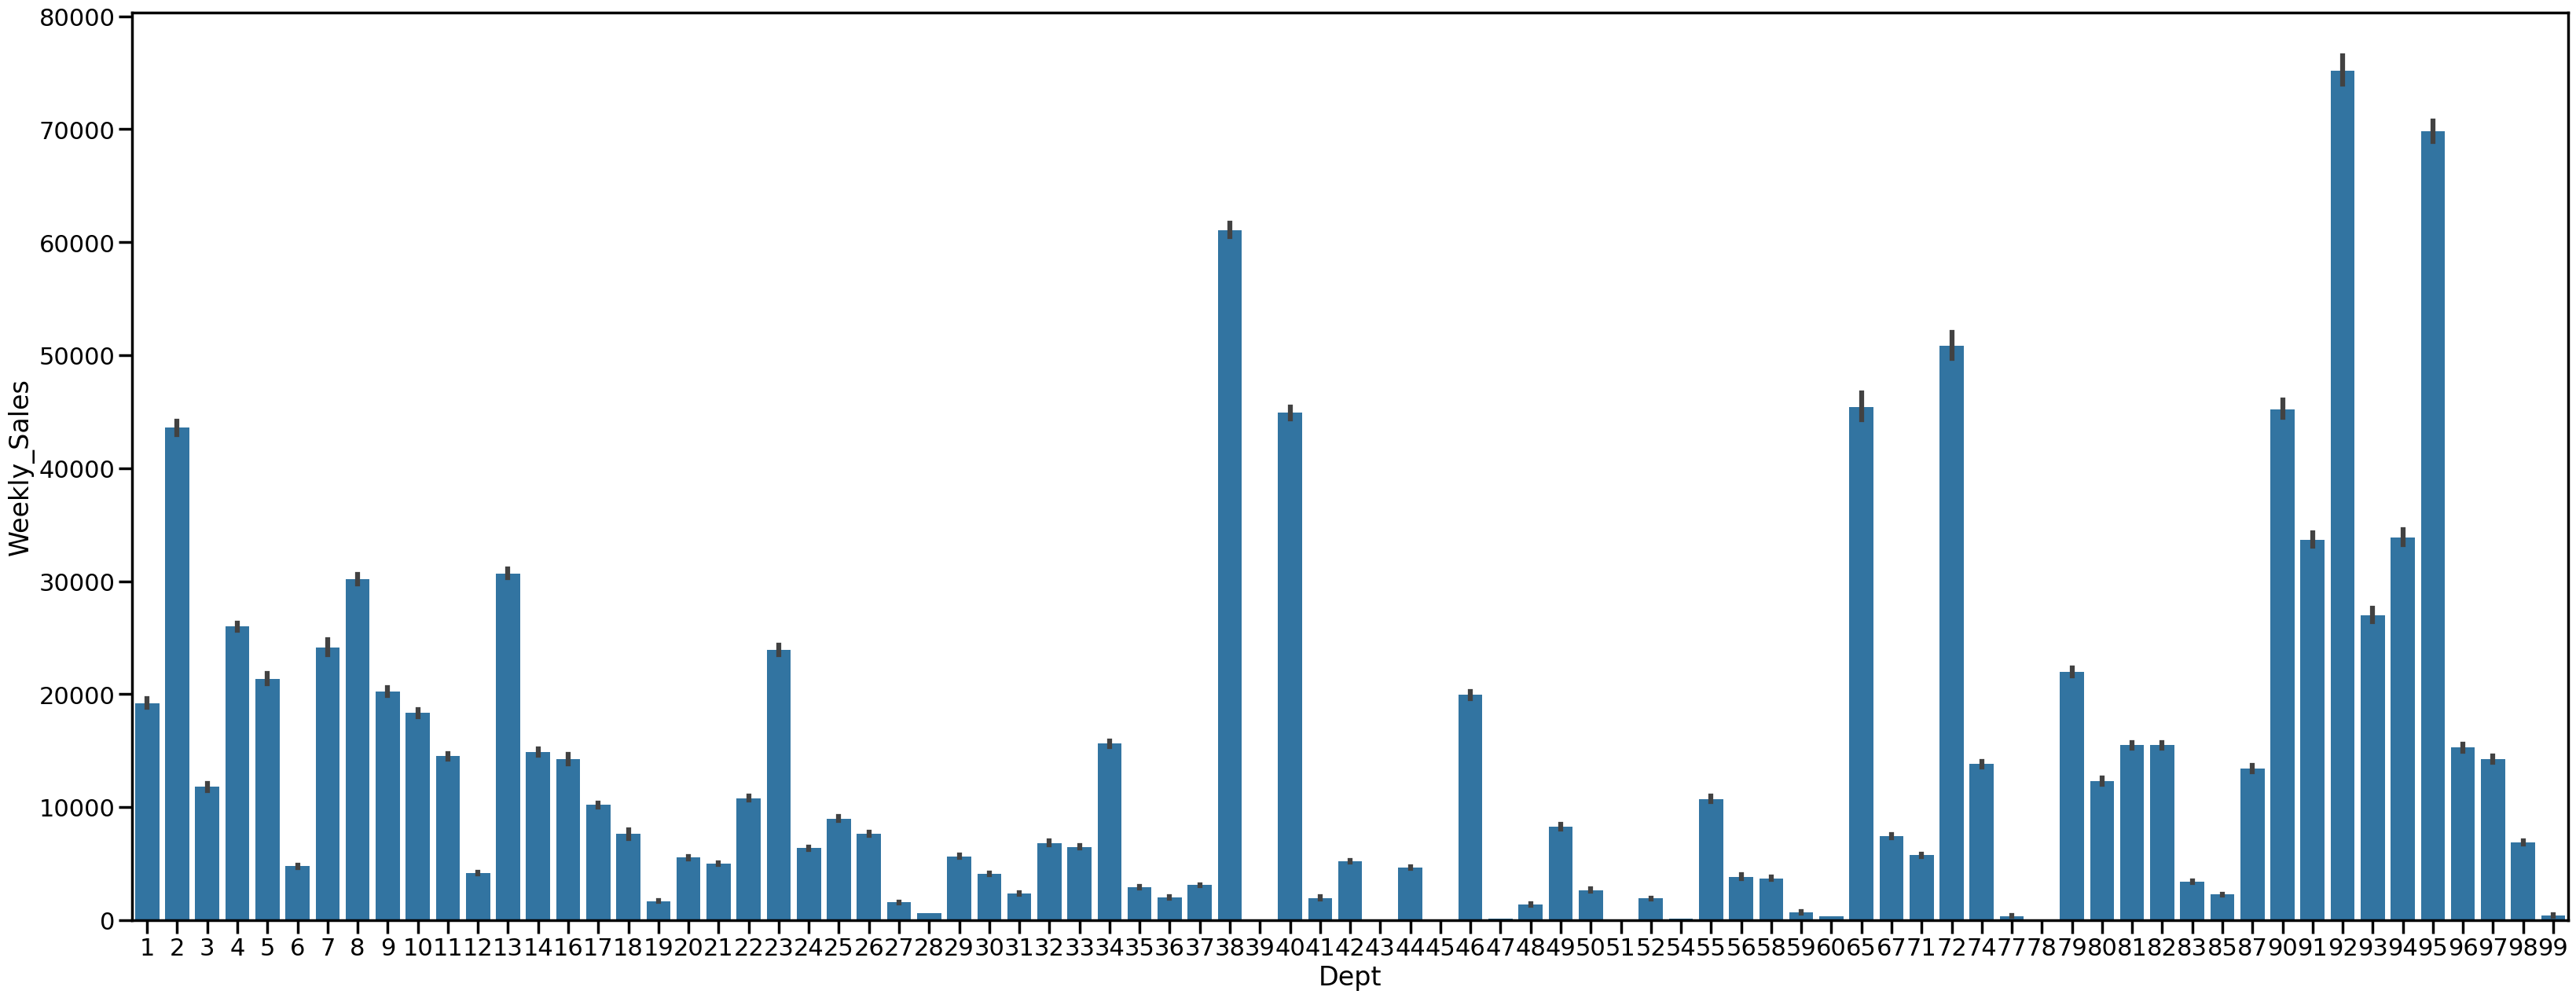

In [79]:
plt.figure(figsize=(40,15))
fig = sns.barplot(x='Dept', y='Weekly_Sales', data=df)

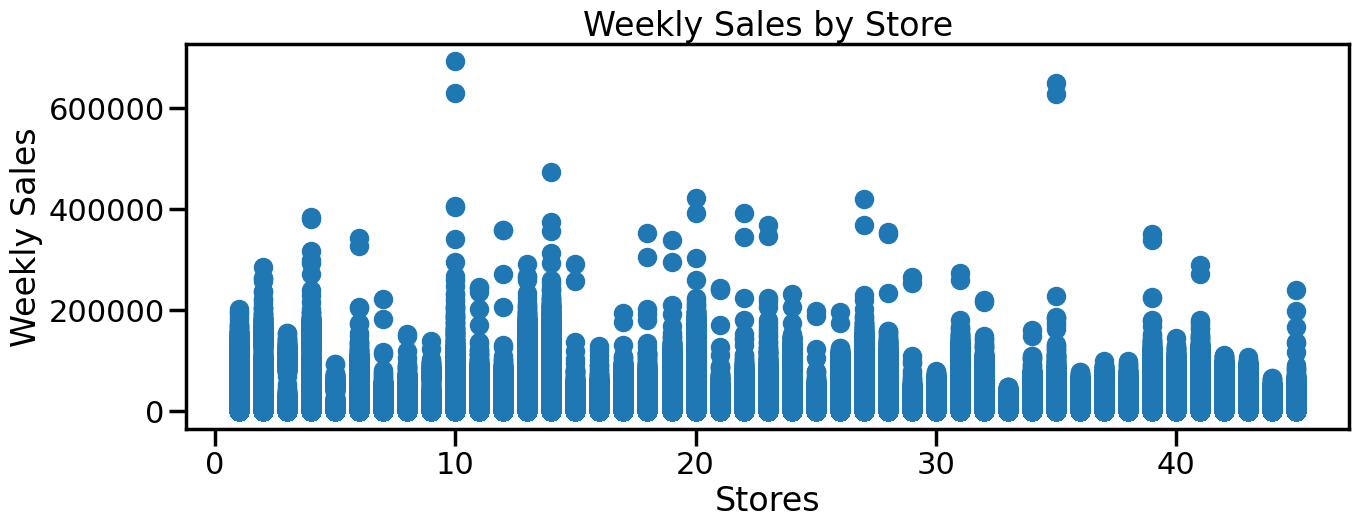

In [80]:
x = df['Store']
y = df['Weekly_Sales']
plt.figure(figsize=(15,5))
plt.title('Weekly Sales by Store')
plt.xlabel('Stores')
plt.ylabel('Weekly Sales')
plt.scatter(x,y)
plt.show()

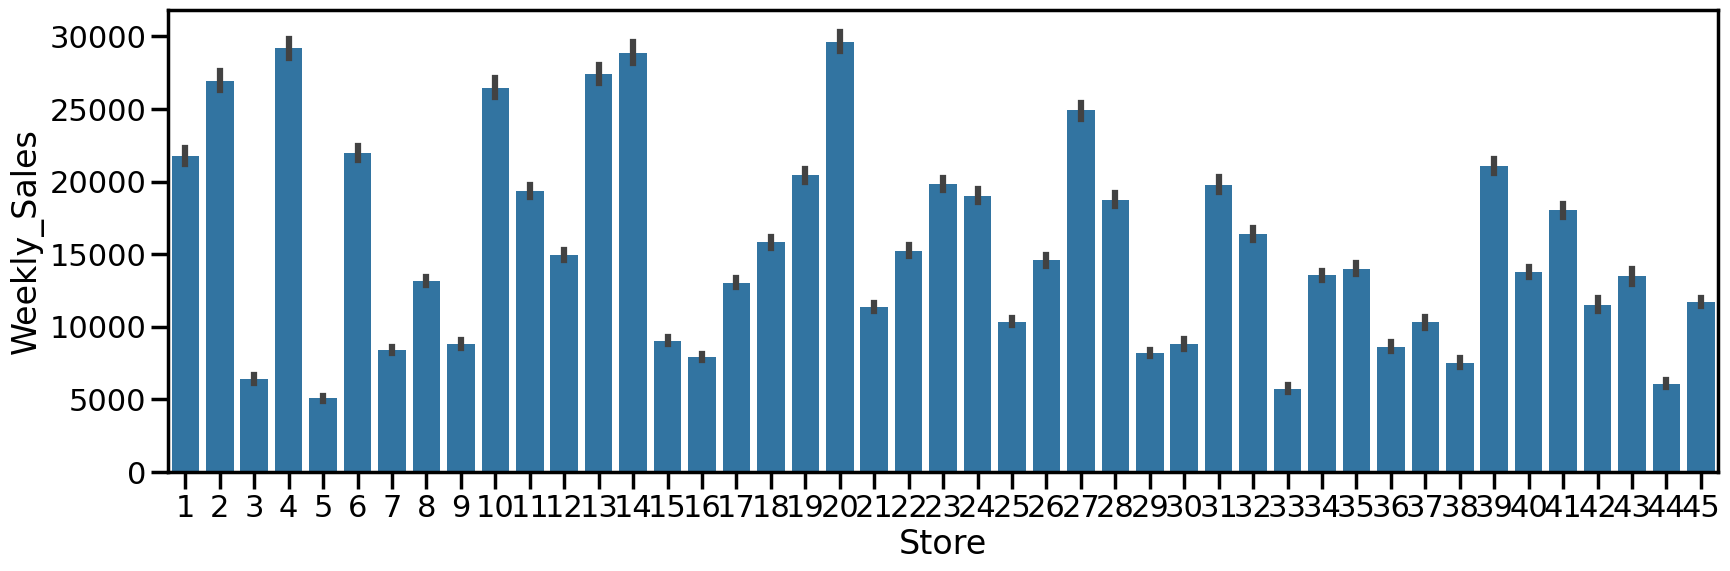

In [81]:
plt.figure(figsize=(20,6))
fig = sns.barplot(x='Store', y='Weekly_Sales', data=df)

In [82]:
df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

In [83]:
df['week'] = df['Date'].dt.isocalendar().week

In [84]:
df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,Type,Size,Super_Bowl,Labor_Day,Thanksgiving,Christmas,before_Christmas,month,year,week
0,1,2010-02-05,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,...,A,151315,False,False,False,False,False,2,2010,5
1,1,2010-02-05,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,...,A,151315,False,False,False,False,False,2,2010,5
2,1,2010-02-05,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,...,A,151315,False,False,False,False,False,2,2010,5
3,1,2010-02-05,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,...,A,151315,False,False,False,False,False,2,2010,5
4,1,2010-02-05,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,...,A,151315,False,False,False,False,False,2,2010,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,B,118221,False,False,False,False,False,10,2012,43
421566,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,B,118221,False,False,False,False,False,10,2012,43
421567,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,B,118221,False,False,False,False,False,10,2012,43
421568,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,B,118221,False,False,False,False,False,10,2012,43


In [85]:
df.groupby('month')['Weekly_Sales'].mean()

month
1     14182.239153
2     16048.701191
3     15464.817698
4     15696.435193
5     15845.556200
6     16397.605478
7     15905.472425
8     16113.800069
9     15147.216063
10    15279.182119
11    17534.964277
12    19425.798603
Name: Weekly_Sales, dtype: float64

In [86]:
df.groupby('year')['Weekly_Sales'].mean()

year
2010    16318.648285
2011    16007.797985
2012    15748.265005
Name: Weekly_Sales, dtype: float64

<Axes: xlabel='month'>

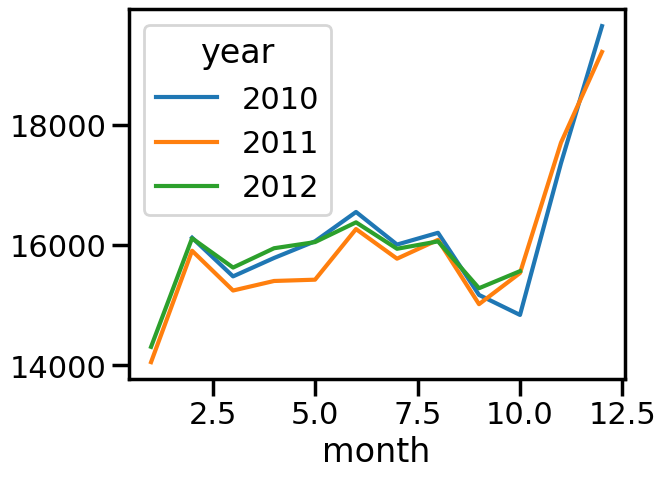

In [87]:
monthly_sales = pd.pivot_table(df, columns='year', index='month', values='Weekly_Sales')
monthly_sales.plot()

In [88]:
monthly_sales

year,2010,2011,2012
month,,,
1,NaN,14054.378885,14308.409638
2,16123.339183,15906.833033,16114.205186
3,15480.222209,15245.219561,15626.987004
4,15786.479121,15403.855679,15948.226550
5,16063.976174,15425.362450,16050.428765
6,16551.606753,16267.355096,16379.278462
7,16009.268745,15774.614002,15939.415690
8,16205.333619,16088.169620,16062.301274
9,15172.175282,15018.049242,15283.248527


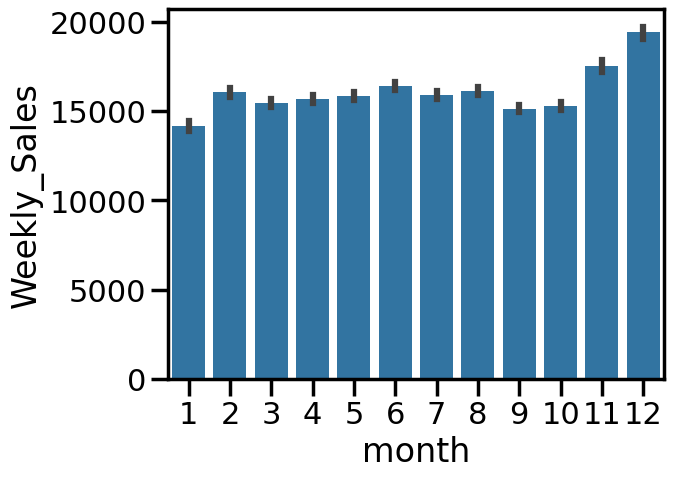

In [89]:
fig = sns.barplot(x='month', y='Weekly_Sales', data=df)

In [90]:
df.groupby('week')['Weekly_Sales'].mean().sort_values(ascending=False).head()

week
51    26454.164116
47    22269.601768
50    20478.421134
49    18731.794840
22    16856.650245
Name: Weekly_Sales, dtype: float64

<Axes: xlabel='week'>

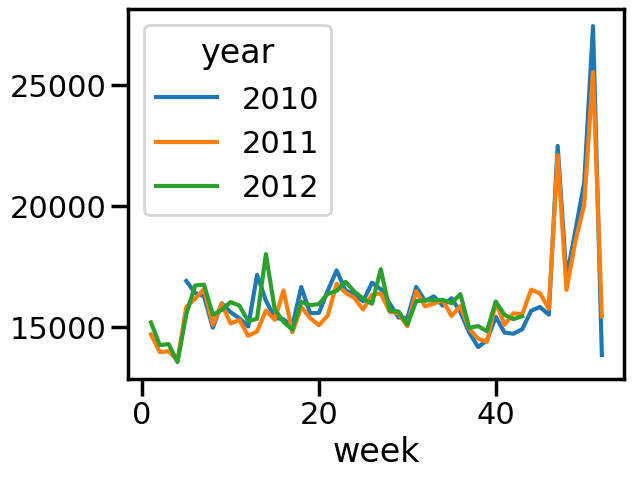

In [91]:
weekly_sales = pd.pivot_table(df, values = 'Weekly_Sales', columns='year', index='week')
weekly_sales.plot()

In [92]:
weekly_sales

year,2010,2011,2012
week,,,
1,NaN,14679.587323,15172.381502
2,NaN,13948.508567,14240.431552
3,NaN,13985.160065,14279.630241
4,NaN,13603.701992,13535.547791
5,16887.602166,15822.286850,15511.884823
6,16390.912208,16155.910205,16703.472478
7,16255.185970,16558.869701,16738.021167
8,14955.932194,15085.818752,15489.637807
9,15964.821240,15947.340322,15693.684826


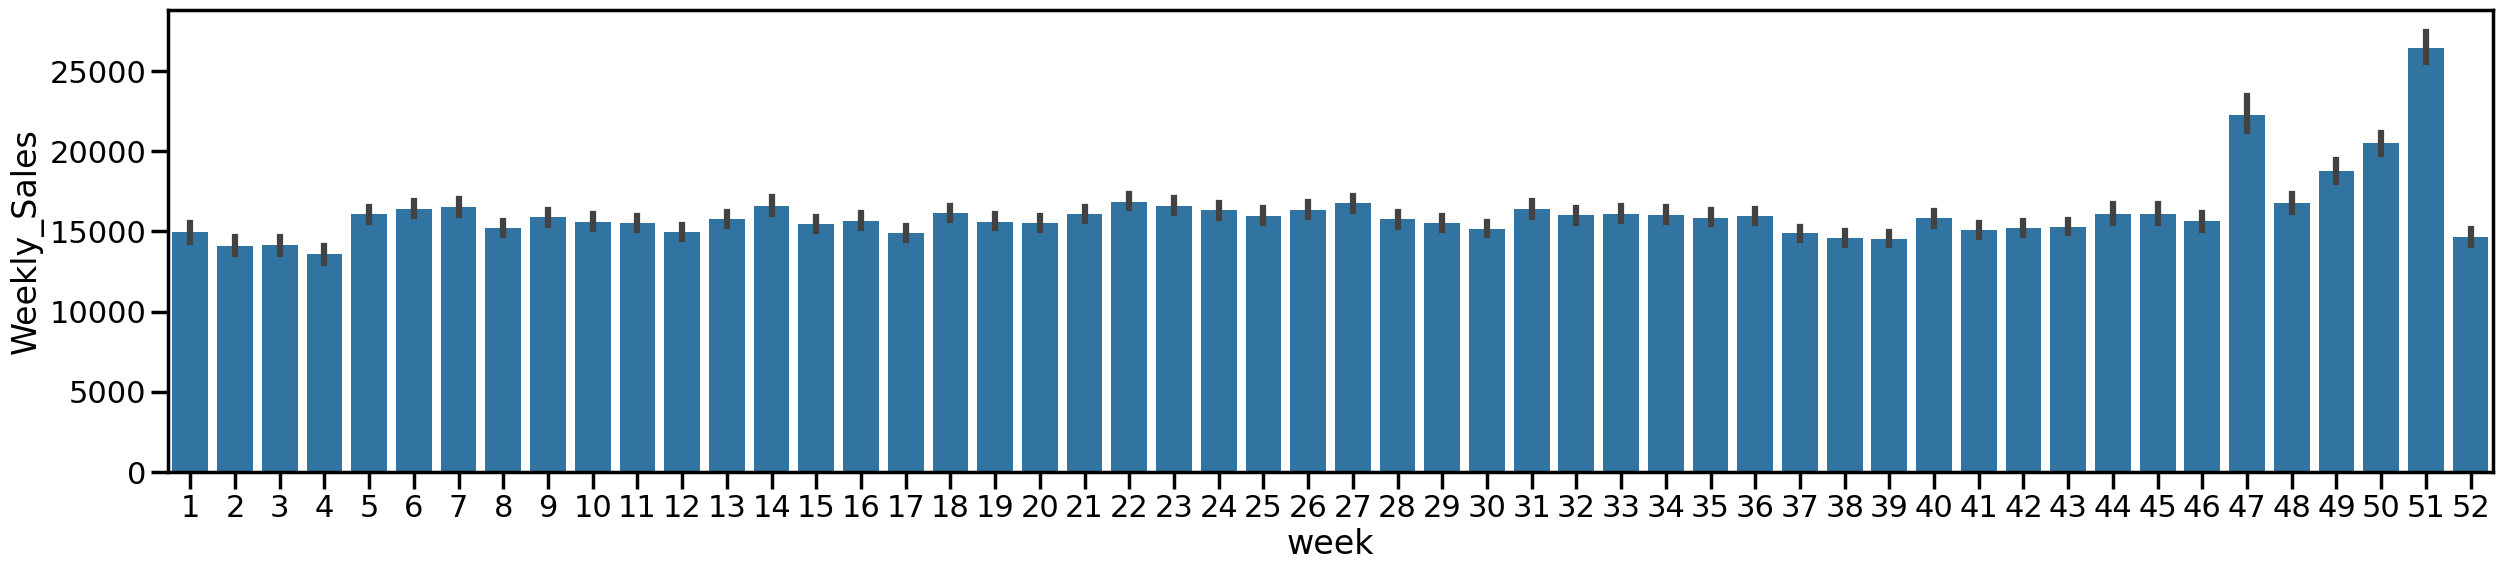

In [93]:
plt.figure(figsize=(30,6))
fig = sns.barplot(x='week', y='Weekly_Sales', data=df)

<Axes: xlabel='Fuel_Price'>

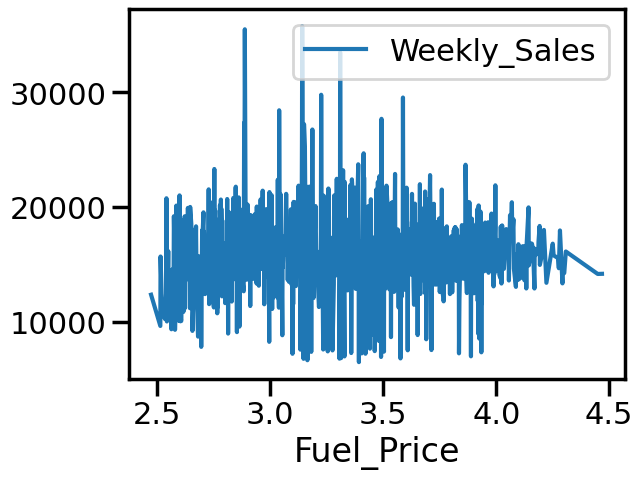

In [94]:
fuel_price = pd.pivot_table(df, values='Weekly_Sales', index='Fuel_Price')
fuel_price.plot()

<Axes: xlabel='Temperature'>

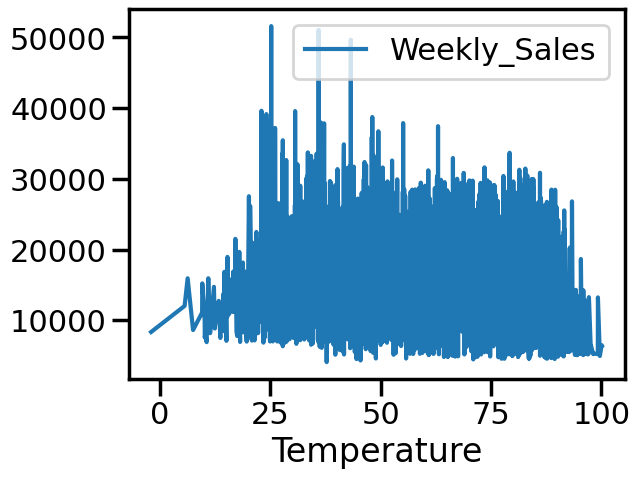

In [95]:
temperature = pd.pivot_table(df, values='Weekly_Sales', index='Temperature')
temperature.plot()

<Axes: xlabel='CPI'>

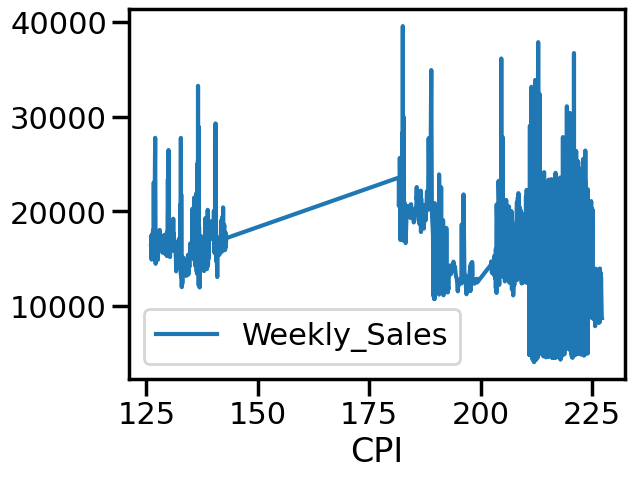

In [96]:
cpi = pd.pivot_table(df, values='Weekly_Sales', index='CPI')
cpi.plot()

<Axes: xlabel='Unemployment'>

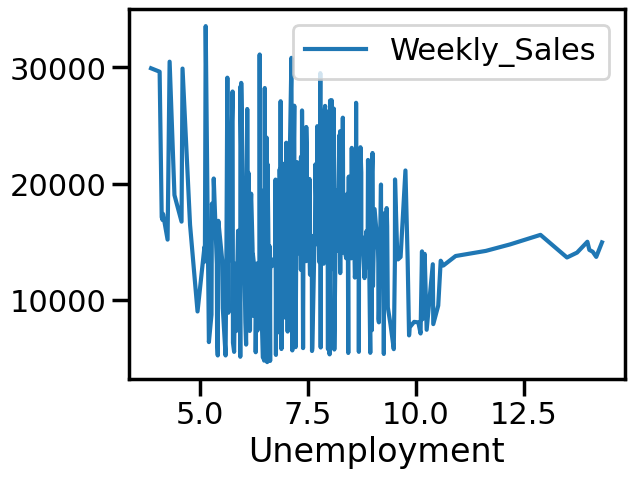

In [98]:
unemployment = pd.pivot_table(df, values='Weekly_Sales', index='Unemployment')
unemployment.plot()

In [101]:
df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday', 'Dept', 'Weekly_Sales', 'Type', 'Size', 'Super_Bowl',
       'Labor_Day', 'Thanksgiving', 'Christmas', 'before_Christmas', 'month',
       'year', 'week'],
      dtype='object')

In [102]:
df['Unemployment']

0         8.106
1         8.106
2         8.106
3         8.106
4         8.106
          ...  
421565    8.667
421566    8.667
421567    8.667
421568    8.667
421569    8.667
Name: Unemployment, Length: 420212, dtype: float64

In [103]:
df.to_csv('clean_data.csv')

# Findings & Insights:

## Data Sourcing:
- Data is downloaded from kaggle, dataset- https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast
- Dataset consist of data of Walmart stores sales in year 2010, 2011, 2012.
- Provides features such as Date, Markdowns, Holidays, FuelPrice, Temperature, CPI.

## Data Cleaning:
- Very less null values were found in the columns
- I choose rows with values greater than 0 for weekly sales. Nearly 0.3% values were negative so i dropped them.
- Null values in the Markdown column were changed to zero, for better calculation purpose.

## Explorations:
- There are a total of 45 stores in the dataset, with total 81 departments as department A,B and C.
- The holiday dates in the dataset shows four main holidays which are Christmas, Thanksgiving, SuperBowl and Labor Day.
- So the weekly sales were compared with each holiday dates to get proper insights about weekly sales on specific holidays.
- Thanksgiving showed the most effect on sales, while other holidays had no great differences.I have also checked for dates immediate before Christmas    which showed a great jump in sales than on normal days.
- Stores has 3 types as A, B and C according to their sizes. Almost half of the stores are bigger than 150000 and categorized as A. According to type,    sales of the stores are changing.
- Department 72 has the highest weekly sales but on average department 92 is seen as the highest. It is observed that top five highest weekly sales are   from department 72 on Thanksgiving dates.
- Talking about stores, store no. 10 and 35 have the highest weekly sales and on an average store no. 4 and 20 are the highest in weekly sales. This      change is observed due to seasonal sales.
- Year 2010 has higher sales than 2011 and 2012. But, November and December sales are not in the data for 2012. Even without highest sale months, 2012    is not significantly less than 2010, so it can be assumed that 2012 could have higher sales.
- It is obviously seen that week 51 and 47 have higher values and 50-48 weeks follow them. Interestingly, 5th top sales belongs to 22th week of the       year. This results show that Christmas, Thankgiving and Black Friday are very important than other weeks for sales and 5th important time is 22th       week of the year and it is end of the May, when schools are closed. Most probably, people are preparing for holiday at the end of the May.
- January sales are significantly less than other months.
- CPI, temperature, unemployment rate and fuel price have no pattern on weekly sales.
